# Pipeline complet :
split chronologique /n
normalisation
architecture du LSTM network (avec pytorch)
training 
test 
validate 
visualise metrics 
backpropagate 
optimize 
train 
evaluate
generalize the model to see it in an backtest environment

In [31]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset,DataLoader
import copy
import random
import time
import torch.nn as nn

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [3]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Selected device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

Selected device: cuda
GPU: NVIDIA GeForce RTX 3080


In [4]:
def find_project_root(
    marker: str = "pyproject.toml",
) -> Path:

    start = Path.cwd().resolve()

    for candidate in (start, *start.parents):
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(
        f"Project root not found. Missing: {marker}"
    )


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

MODEL_DIR = (
    PROJECT_ROOT / "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


DATA_FILE = (
    PROCESSED_DIR / "lstm_mse_features.csv"
)

SCALER_FILE = (
    MODEL_DIR / "lstm_mse_standard_scaler.joblib"
)


assert DATA_FILE.exists(), (
    f"Dataset not found: {DATA_FILE}"
)

print("Dataset:", DATA_FILE)

Dataset: C:\Users\SETUP GAME\OneDrive\Desktop\Sun_project\Time_series_momentum\data\processed\lstm_mse_features.csv


In [5]:
data = pd.read_csv(
    DATA_FILE,
    parse_dates=["date"],
)

data = (
    data
    .sort_values(["date", "ticker"])
    .reset_index(drop=True)
)

print("Dataset shape:", data.shape)
print("First date   :", data["date"].min())
print("Last date    :", data["date"].max())
print("Tickers      :", data["ticker"].nunique())

display(data.head())

Dataset shape: (209560, 15)
First date   : 1981-05-15 00:00:00
Last date    : 2026-09-03 00:00:00
Tickers      : 20


,date,ticker,close,daily_return,daily_volatility,annualized_volatility,momentum_1d,momentum_21d,momentum_63d,momentum_126d,momentum_252d,macd_8_24,macd_16_48,macd_32_96,target_next_return
0,1981-05-15,BA,2.000258,0.023166,0.018620,0.295586,1.244116,-0.508468,-0.270369,-0.743424,0.075599,-2.216649,-2.684895,-2.574580,-0.405322
1,1981-05-15,BAC,0.601559,-0.008266,0.015625,0.248044,-0.528985,-0.974350,0.278032,0.692702,0.287965,-0.196035,1.031123,1.653529,0.533393
2,1981-05-15,CAT,3.085341,-0.003572,0.014279,0.226673,-0.250165,0.568114,2.141946,1.121173,2.135422,1.361574,2.158168,1.861569,0.000000
3,1981-05-15,CVX,1.823256,0.012580,0.022070,0.350351,0.569985,0.284305,-0.727104,-0.733452,0.627079,-0.255012,-1.111408,-0.441496,0.000000
4,1981-05-15,GE,1.995885,0.011741,0.012861,0.204166,0.912899,-0.416173,0.635941,1.028739,2.167266,-0.955768,2.010544,3.423315,0.451141


In [6]:
FEATURE_COLUMNS = [
    "momentum_1d",
    "momentum_21d",
    "momentum_63d",
    "momentum_126d",
    "momentum_252d",
    "macd_8_24",
    "macd_16_48",
    "macd_32_96",
    "annualized_volatility",
]

TARGET_COLUMN = "target_next_return"

In [7]:
required_columns = [
    "date",
    "ticker",
    *FEATURE_COLUMNS,
    TARGET_COLUMN,
]

missing_columns = [
    column
    for column in required_columns
    if column not in data.columns
]

assert not missing_columns, (
    f"Missing columns: {missing_columns}"
)

assert not data[required_columns].isna().any().any()

assert np.isfinite(
    data[
        FEATURE_COLUMNS + [TARGET_COLUMN]
    ].to_numpy()
).all()

assert not data.duplicated(
    subset=["date", "ticker"]
).any()

print("Dataset successfully validated.")

Dataset successfully validated.


Split chronologique (timeseriessplit)

In [8]:
TRAIN_END = pd.Timestamp("2016-12-31")

VALIDATION_START = pd.Timestamp("2017-01-01")
VALIDATION_END = pd.Timestamp("2019-12-31")

TEST_START = pd.Timestamp("2020-01-01")

In [9]:
train_data = data.loc[
    data["date"] <= TRAIN_END
].copy()

validation_data = data.loc[
    data["date"].between(
        VALIDATION_START,
        VALIDATION_END,
    )
].copy()

test_data = data.loc[
    data["date"] >= TEST_START
].copy()

In [10]:
def describe_split(
    name: str,
    dataset: pd.DataFrame,
) -> dict:

    return {
        "split": name,
        "first_date": dataset["date"].min(),
        "last_date": dataset["date"].max(),
        "rows": len(dataset),
        "tickers": dataset["ticker"].nunique(),
    }


split_report = pd.DataFrame([
    describe_split("train", train_data),
    describe_split("validation", validation_data),
    describe_split("test", test_data),
])

display(split_report)

,split,first_date,last_date,rows,tickers
0,train,1981-05-15,2016-12-30,160940,20
1,validation,2017-01-03,2019-12-31,15080,20
2,test,2020-01-02,2026-09-03,33540,20


In [11]:
assert not train_data.empty
assert not validation_data.empty
assert not test_data.empty

assert train_data["date"].max() < (
    validation_data["date"].min()
)

assert validation_data["date"].max() < (
    test_data["date"].min()
)

assert train_data["date"].max() <= TRAIN_END

assert validation_data["date"].min() >= (
    VALIDATION_START
)

assert validation_data["date"].max() <= (
    VALIDATION_END
)

assert test_data["date"].min() >= TEST_START

print("Chronological split successfully validated.")

Chronological split successfully validated.


In [12]:
assert not train_data.empty
assert not validation_data.empty
assert not test_data.empty

assert train_data["date"].max() < (
    validation_data["date"].min()
)

assert validation_data["date"].max() < (
    test_data["date"].min()
)

assert train_data["date"].max() <= TRAIN_END

assert validation_data["date"].min() >= (
    VALIDATION_START
)

assert validation_data["date"].max() <= (
    VALIDATION_END
)

assert test_data["date"].min() >= TEST_START

print("Chronological split successfully validated.")

Chronological split successfully validated.


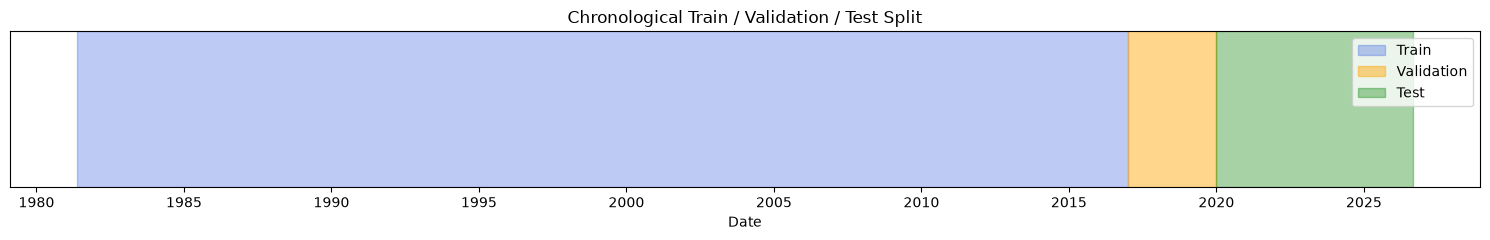

In [13]:
plt.figure(figsize=(15, 2.5))

plt.axvspan(
    data["date"].min(),
    TRAIN_END,
    color="royalblue",
    alpha=0.35,
    label="Train",
)

plt.axvspan(
    VALIDATION_START,
    VALIDATION_END,
    color="orange",
    alpha=0.45,
    label="Validation",
)

plt.axvspan(
    TEST_START,
    data["date"].max(),
    color="green",
    alpha=0.35,
    label="Test",
)

plt.yticks([])
plt.xlabel("Date")
plt.title("Chronological Train / Validation / Test Split")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
scaler=StandardScaler()
scaler.fit(
    train_data[FEATURE_COLUMNS]
)

StandardScaler()

In [15]:
train_scaled = train_data.copy()
validation_scaled = validation_data.copy()
test_scaled = test_data.copy()
train_scaled[FEATURE_COLUMNS] = (
    scaler.transform(
        train_data[FEATURE_COLUMNS]
    )
)

validation_scaled[FEATURE_COLUMNS] = (
    scaler.transform(
        validation_data[FEATURE_COLUMNS]
    )
)

test_scaled[FEATURE_COLUMNS] = (
    scaler.transform(
        test_data[FEATURE_COLUMNS]
    )
)

In [16]:
scaling_report = pd.DataFrame({
    "train_mean": (
        train_scaled[FEATURE_COLUMNS].mean()
    ),
    "train_std": (
        train_scaled[FEATURE_COLUMNS].std(ddof=0)
    ),
    "validation_mean": (
        validation_scaled[FEATURE_COLUMNS].mean()
    ),
    "validation_std": (
        validation_scaled[FEATURE_COLUMNS].std(ddof=0)
    ),
    "test_mean": (
        test_scaled[FEATURE_COLUMNS].mean()
    ),
    "test_std": (
        test_scaled[FEATURE_COLUMNS].std(ddof=0)
    ),
})

display(scaling_report)

,train_mean,train_std,validation_mean,validation_std,test_mean,test_std
momentum_1d,0.000000,1.000000,0.014121,1.008631,-0.007105,1.018083
momentum_21d,0.000000,1.000000,0.067049,1.028688,-0.017639,1.044047
momentum_63d,0.000000,1.000000,0.121101,1.055367,-0.015354,1.015889
momentum_126d,-0.000000,1.000000,0.139531,1.079765,-0.026209,1.006335
momentum_252d,-0.000000,1.000000,0.182078,1.060271,-0.037479,0.974396
macd_8_24,-0.000000,1.000000,0.161080,1.089173,-0.048869,0.984235
macd_16_48,0.000000,1.000000,0.099746,0.998266,-0.106410,0.879004
macd_32_96,0.000000,1.000000,0.122143,0.890913,-0.104677,0.888442
annualized_volatility,0.000000,1.000000,-0.578265,0.443746,-0.028904,0.775681


In [17]:
assert np.allclose(
    train_scaled[TARGET_COLUMN],
    train_data[TARGET_COLUMN],
)

assert np.allclose(
    validation_scaled[TARGET_COLUMN],
    validation_data[TARGET_COLUMN],
)

assert np.allclose(
    test_scaled[TARGET_COLUMN],
    test_data[TARGET_COLUMN],
)

print("The target was not transformed.")

The target was not transformed.


In [18]:
joblib.dump(
    scaler,
    SCALER_FILE,
)

print("Scaler saved:", SCALER_FILE)

Scaler saved: C:\Users\SETUP GAME\OneDrive\Desktop\Sun_project\Time_series_momentum\models\lstm_mse_standard_scaler.joblib


In [19]:
train_scaled.to_parquet(
    PROCESSED_DIR / "lstm_mse_train_scaled.parquet",
    index=False,
)

validation_scaled.to_parquet(
    PROCESSED_DIR / "lstm_mse_validation_scaled.parquet",
    index=False,
)

test_scaled.to_parquet(
    PROCESSED_DIR / "lstm_mse_test_scaled.parquet",
    index=False,
)

print("Scaled chronological datasets saved.")

Scaled chronological datasets saved.


In [21]:
SEQUENCE_LENGTH = 63
BATCH_SIZE = 256

NUM_WORKERS = 0

In [22]:
scaled_data = (
    pd.concat(
        [
            train_scaled,
            validation_scaled,
            test_scaled,
        ],
        axis=0,
        ignore_index=True,
    )
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

In [23]:
scaled_data["split"] = np.select(
    [
        scaled_data["date"] <= TRAIN_END,

        scaled_data["date"].between(
            VALIDATION_START,
            VALIDATION_END,
        ),

        scaled_data["date"] >= TEST_START,
    ],
    [
        "train",
        "validation",
        "test",
    ],
    default="excluded",
)

Neural network sequentiel model !

In [24]:
class FinancialSequenceDataset(Dataset):

    def __init__(
        self,
        dataframe: pd.DataFrame,
        feature_columns: list[str],
        target_column: str,
        split_name: str,
        sequence_length: int = 63,
    ):

        self.feature_columns = feature_columns
        self.target_column = target_column
        self.sequence_length = sequence_length
        self.split_name = split_name

        self.ticker_data = {}
        self.sample_index = []

        for ticker, ticker_frame in dataframe.groupby(
            "ticker",
            sort=False,
        ):

            ticker_frame = (
                ticker_frame
                .sort_values("date")
                .reset_index(drop=True)
            )

            features = ticker_frame[
                feature_columns
            ].to_numpy(dtype=np.float32)

            targets = ticker_frame[
                target_column
            ].to_numpy(dtype=np.float32)

            dates = ticker_frame[
                "date"
            ].to_numpy()

            splits = ticker_frame[
                "split"
            ].to_numpy()

            self.ticker_data[ticker] = {
                "features": features,
                "targets": targets,
                "dates": dates,
            }

            for end_position in range(
                sequence_length - 1,
                len(ticker_frame),
            ):

                if splits[end_position] == split_name:

                    self.sample_index.append(
                        (ticker, end_position)
                    )

    def __len__(self):

        return len(self.sample_index)

    def __getitem__(self, index):

        ticker, end_position = (
            self.sample_index[index]
        )

        ticker_values = self.ticker_data[ticker]

        start_position = (
            end_position
            - self.sequence_length
            + 1
        )

        sequence = ticker_values["features"][
            start_position:end_position + 1
        ]

        target = ticker_values["targets"][
            end_position
        ]

        return (
            torch.from_numpy(sequence),
            torch.tensor(
                target,
                dtype=torch.float32,
            ),
        )

    def get_metadata(self, index):

        ticker, end_position = (
            self.sample_index[index]
        )

        values = self.ticker_data[ticker]

        return {
            "ticker": ticker,
            "date": values["dates"][end_position],
        }

In [25]:
train_dataset = FinancialSequenceDataset(
    dataframe=scaled_data,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    split_name="train",
    sequence_length=SEQUENCE_LENGTH,
)

validation_dataset = FinancialSequenceDataset(
    dataframe=scaled_data,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    split_name="validation",
    sequence_length=SEQUENCE_LENGTH,
)

test_dataset = FinancialSequenceDataset(
    dataframe=scaled_data,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    split_name="test",
    sequence_length=SEQUENCE_LENGTH,
)

In [26]:
print("Train sequences     :", len(train_dataset))
print("Validation sequences:", len(validation_dataset))
print("Test sequences      :", len(test_dataset))

Train sequences     : 159700
Validation sequences: 15080
Test sequences      : 33540


In [27]:
assert len(train_dataset) > 0
assert len(validation_dataset) > 0
assert len(test_dataset) > 0

print("All sequence datasets were created.")

All sequence datasets were created.


In [28]:
sample_sequence, sample_target = (
    train_dataset[0]
)

print("Sequence shape:", sample_sequence.shape)
print("Target shape  :", sample_target.shape)
print("Target value  :", sample_target.item())
print("Metadata      :", train_dataset.get_metadata(0))

Sequence shape: torch.Size([63, 9])
Target shape  : torch.Size([])
Target value  : -1.5323700904846191
Metadata      : {'ticker': 'AAPL', 'date': np.datetime64('1982-07-27T00:00:00.000000')}


In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

In [30]:
batch_sequences, batch_targets = next(
    iter(train_loader)
)

print("Batch sequences:", batch_sequences.shape)
print("Batch targets  :", batch_targets.shape)

Batch sequences: torch.Size([256, 63, 9])
Batch targets  : torch.Size([256])


In [32]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [33]:
INPUT_SIZE = len(FEATURE_COLUMNS)

HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT_RATE = 0.20

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

GRADIENT_CLIP = 1.0

In [34]:
class LSTMMSEModel(nn.Module):

    def __init__(
        self,
        input_size: int,
        hidden_size: int = 32,
        num_layers: int = 1,
        dropout_rate: float = 0.20,
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.dropout = nn.Dropout(
            p=dropout_rate
        )

        self.output_layer = nn.Linear(
            in_features=hidden_size,
            out_features=1,
        )

    def forward(
        self,
        sequences: torch.Tensor,
    ) -> torch.Tensor:

        lstm_output, _ = self.lstm(
            sequences
        )

        last_hidden_state = (
            lstm_output[:, -1, :]
        )

        last_hidden_state = self.dropout(
            last_hidden_state
        )

        prediction = self.output_layer(
            last_hidden_state
        )

        return prediction.squeeze(-1)

In [35]:
model = LSTMMSEModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout_rate=DROPOUT_RATE,
)

model = model.to(DEVICE)

print(model)

LSTMMSEModel(
  (lstm): LSTM(9, 32, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [36]:
number_of_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters    :", number_of_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters    : 5537
Trainable parameters: 5537


In [37]:
batch_sequences, batch_targets = next(
    iter(train_loader)
)

batch_sequences = batch_sequences.to(DEVICE)
batch_targets = batch_targets.to(DEVICE)

with torch.no_grad():
    batch_predictions = model(
        batch_sequences
    )

print("Input shape      :", batch_sequences.shape)
print("Prediction shape :", batch_predictions.shape)
print("Target shape     :", batch_targets.shape)

Input shape      : torch.Size([256, 63, 9])
Prediction shape : torch.Size([256])
Target shape     : torch.Size([256])


In [38]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

In [39]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device,
    gradient_clip=1.0,
):

    model.train()

    total_loss = 0.0
    total_observations = 0

    for sequences, targets in data_loader:

        sequences = sequences.to(
            device,
            non_blocking=True,
        )

        targets = targets.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        predictions = model(sequences)

        loss = criterion(
            predictions,
            targets,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=gradient_clip,
        )

        optimizer.step()

        batch_size = sequences.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_observations += batch_size

    return total_loss / total_observations

In [40]:
def evaluate_mse(
    model,
    data_loader,
    criterion,
    device,
):

    model.eval()

    total_loss = 0.0
    total_observations = 0

    with torch.no_grad():

        for sequences, targets in data_loader:

            sequences = sequences.to(
                device,
                non_blocking=True,
            )

            targets = targets.to(
                device,
                non_blocking=True,
            )

            predictions = model(sequences)

            loss = criterion(
                predictions,
                targets,
            )

            batch_size = sequences.size(0)

            total_loss += (
                loss.item() * batch_size
            )

            total_observations += batch_size

    return total_loss / total_observations

In [41]:
validation_targets = np.array([
    validation_dataset[index][1].item()
    for index in range(len(validation_dataset))
])

zero_baseline_mse = np.mean(
    validation_targets ** 2
)

print(
    f"Validation zero-baseline MSE: "
    f"{zero_baseline_mse:.6f}"
)

Validation zero-baseline MSE: 1.072372


In [42]:
training_history = []

best_validation_loss = np.inf
best_epoch = 0
best_model_state = None

epochs_without_improvement = 0

In [43]:
for epoch in range(1, MAX_EPOCHS + 1):

    start_time = time.time()

    train_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        gradient_clip=GRADIENT_CLIP,
    )

    validation_loss = evaluate_mse(
        model=model,
        data_loader=validation_loader,
        criterion=criterion,
        device=DEVICE,
    )

    elapsed_time = time.time() - start_time

    training_history.append({
        "epoch": epoch,
        "train_mse": train_loss,
        "validation_mse": validation_loss,
        "seconds": elapsed_time,
    })

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train MSE: {train_loss:.6f} | "
        f"Validation MSE: {validation_loss:.6f} | "
        f"Time: {elapsed_time:.1f}s"
    )

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "Early stopping activated at "
            f"epoch {epoch}."
        )

        break

Epoch 01/30 | Train MSE: 1.028189 | Validation MSE: 1.069667 | Time: 4.3s
Epoch 02/30 | Train MSE: 1.025672 | Validation MSE: 1.069793 | Time: 3.7s
Epoch 03/30 | Train MSE: 1.025209 | Validation MSE: 1.070084 | Time: 4.1s
Epoch 04/30 | Train MSE: 1.024924 | Validation MSE: 1.070134 | Time: 3.9s
Epoch 05/30 | Train MSE: 1.024639 | Validation MSE: 1.070377 | Time: 4.1s
Epoch 06/30 | Train MSE: 1.024264 | Validation MSE: 1.070370 | Time: 4.0s
Early stopping activated at epoch 6.


In [44]:
assert best_model_state is not None

model.load_state_dict(
    best_model_state
)

print("Best epoch         :", best_epoch)
print(
    f"Best validation MSE: "
    f"{best_validation_loss:.6f}"
)

Best epoch         : 1
Best validation MSE: 1.069667


In [45]:
mse_improvement = (
    zero_baseline_mse
    - best_validation_loss
)

relative_improvement = (
    mse_improvement
    / zero_baseline_mse
)

In [46]:
print(
    f"Zero baseline MSE       : "
    f"{zero_baseline_mse:.6f}"
)

print(
    f"Best LSTM validation MSE: "
    f"{best_validation_loss:.6f}"
)

print(
    f"Relative improvement    : "
    f"{relative_improvement:.2%}"
)

Zero baseline MSE       : 1.072372
Best LSTM validation MSE: 1.069667
Relative improvement    : 0.25%


In [47]:
history_df = pd.DataFrame(
    training_history
)

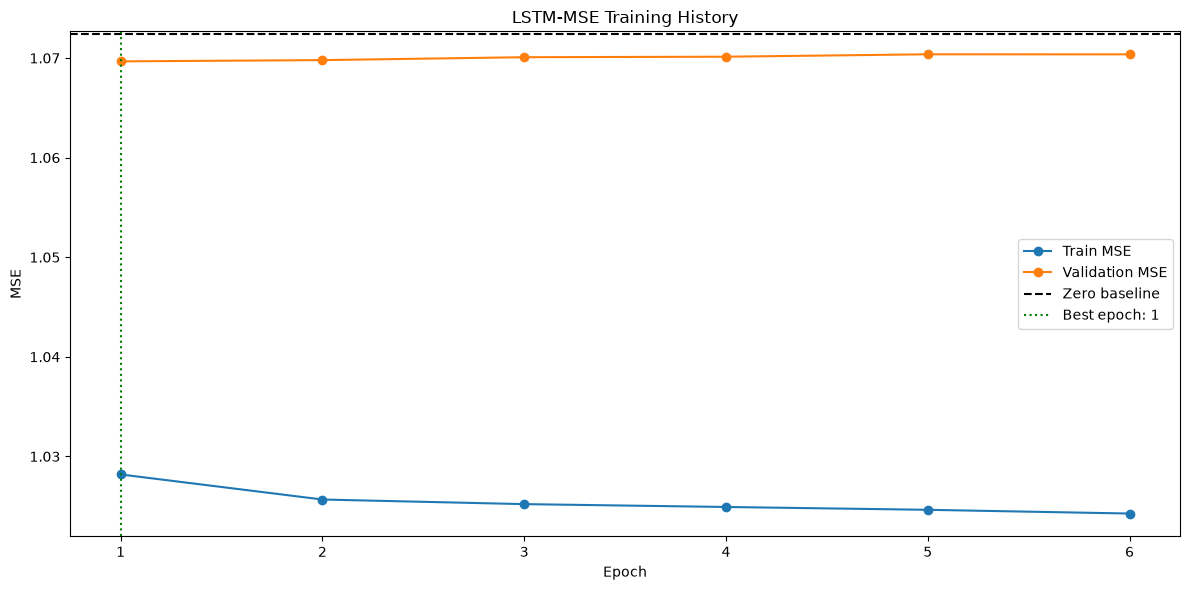

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_mse"],
    marker="o",
    label="Train MSE",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_mse"],
    marker="o",
    label="Validation MSE",
)

plt.axhline(
    zero_baseline_mse,
    color="black",
    linestyle="--",
    label="Zero baseline",
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle=":",
    label=f"Best epoch: {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("LSTM-MSE Training History")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
MODEL_FILE = (
    MODEL_DIR / "lstm_mse_best_model.pt"
)

In [50]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_size": INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout_rate": DROPOUT_RATE,
        "sequence_length": SEQUENCE_LENGTH,
        "feature_columns": FEATURE_COLUMNS,
        "target_column": TARGET_COLUMN,
        "best_epoch": best_epoch,
        "best_validation_mse": (
            best_validation_loss
        ),
        "zero_baseline_mse": (
            zero_baseline_mse
        ),
    },
    MODEL_FILE,
)

print("Best model saved:", MODEL_FILE)

Best model saved: C:\Users\SETUP GAME\OneDrive\Desktop\Sun_project\Time_series_momentum\models\lstm_mse_best_model.pt
